# Andamento Autovetture Elettriche e Ibride per Area Geografica
**Confronto Nord / Centro / Sud — 2015–2023**

Fonte dati: ISTAT — autovetture per 1.000 autovetture circolanti

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [4]:
AREE = ['Nord', 'Centro', 'Sud']
COLORI  = {'Nord': '#00A676', 'Centro': '#FFD23F', 'Sud': '#FF6B35'}
MARKER = {'Nord': 'o',       'Centro': 's',        'Sud': '^'}

## 1. Lettura dei dati

In [5]:
df_el = pd.read_csv('../data/csv/auto_elettr_su_1000.csv', index_col=False)
df_hy = pd.read_csv('../data/csv/auto_ibride_su_1000.csv', index_col=False)

# Converti subito dopo la lettura
df_el['Osservazione'] = pd.to_numeric(df_el['Osservazione'], errors='coerce')
df_hy['Osservazione'] = pd.to_numeric(df_hy['Osservazione'], errors='coerce')

# Verifica
print(df_el['Osservazione'].dtype)  # deve stampare float64

float64


## 2. Filtra le macro aree geografiche (Nord, Centro, Sud)

In [8]:
df_el_aree = df_el[df_el['Territorio'].isin(AREE)].copy()
df_hy_aree = df_hy[df_hy['Territorio'].isin(AREE)].copy()

## 3. Rimozione dei valori NaN

In [9]:
# Debug: controlla NaN dopo conversione
print('NaN elettriche:', df_el_aree['Osservazione'].isna().sum())
print('NaN ibride:', df_hy_aree['Osservazione'].isna().sum())

df_el_aree = df_el_aree[df_el_aree["Osservazione"].notna()]
df_hy_aree = df_hy_aree[df_hy_aree["Osservazione"].notna()]

NaN elettriche: 0
NaN ibride: 0


## 5. Grafico a linee — confronto Nord / Centro / Sud

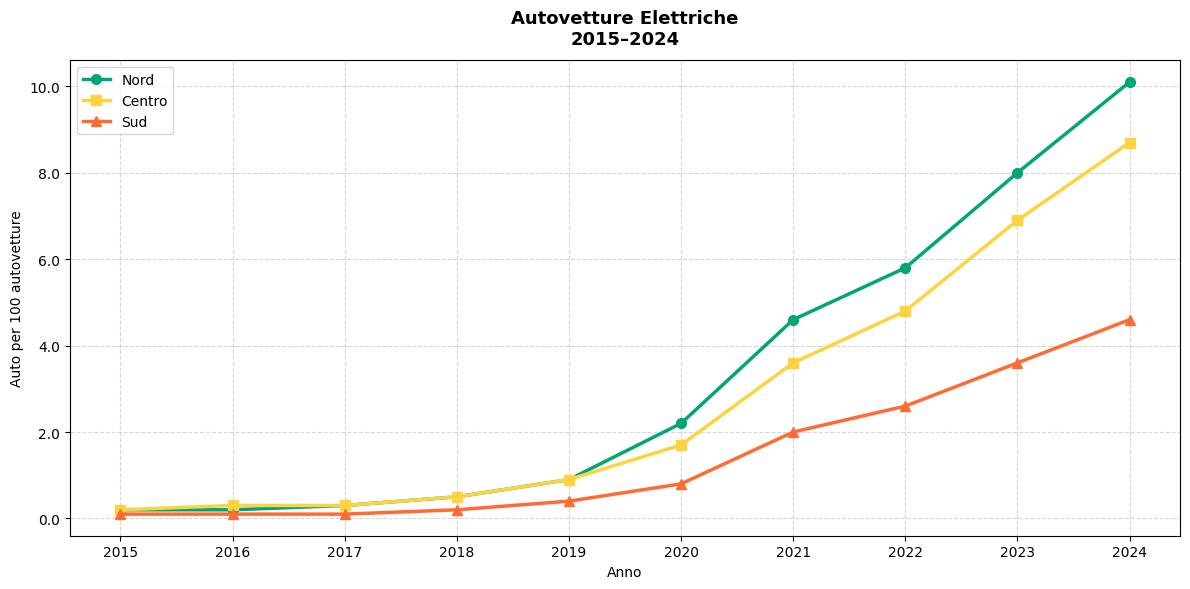

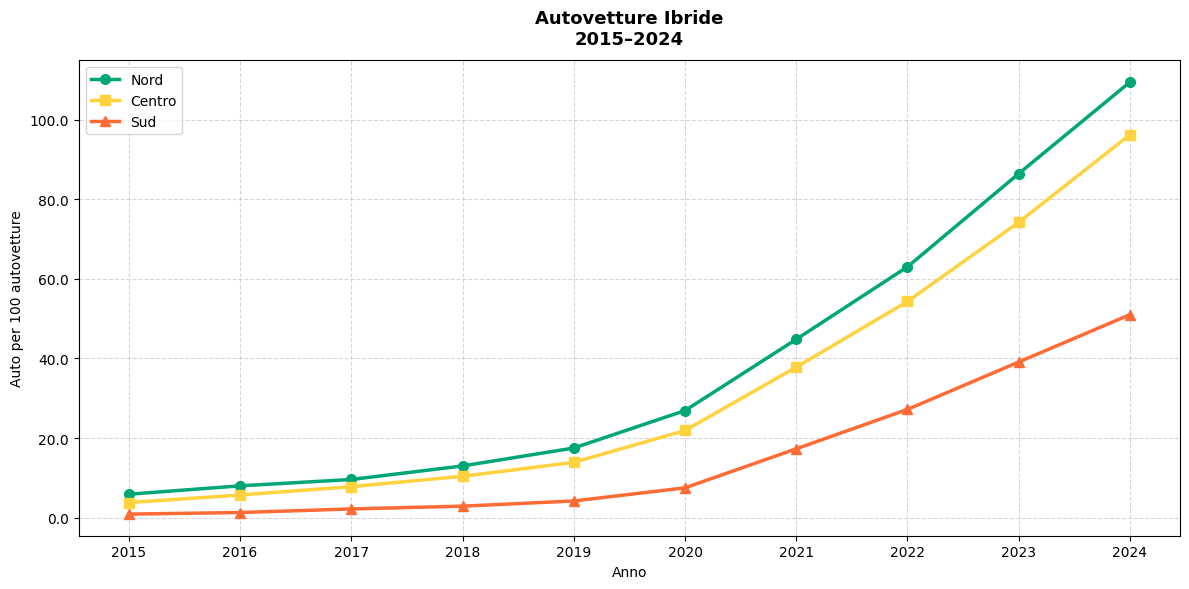

In [10]:
titoli   = ['Autovetture Elettriche', 'Autovetture Ibride']
datasets = [df_el_aree, df_hy_aree]

for df, titolo in zip(datasets, titoli):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for area in AREE:
        dati = df[df['Territorio'] == area].sort_values('TIME_PERIOD')
        ax.plot(
            dati['TIME_PERIOD'], dati['Osservazione'],
            label=area,
            color=COLORI[area],
            marker=MARKER[area],
            linewidth=2.5,
            markersize=7
        )

    ax.set_title(
        f'{titolo}\n2015–2024',
        fontsize=13, fontweight='bold', pad=12
    )
    ax.set_xlabel('Anno', fontsize=10)
    ax.set_ylabel('Auto per 100 autovetture', fontsize=10)
    ax.set_xticks(range(2015, 2025))
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    plt.tight_layout()
    plt.show()

In [16]:
ANNI = sorted(set(df_el_aree['TIME_PERIOD']))
# Funzione per ottenere il valori di un territorio raggruppati per anno
def get_vals(territorio):
    return [
        df_el_aree[
            (df_el_aree['Territorio'] == territorio) &
            (df_el_aree['TIME_PERIOD'] == a)
        ]['Osservazione'].iloc[0]
        for a in ANNI
    ]

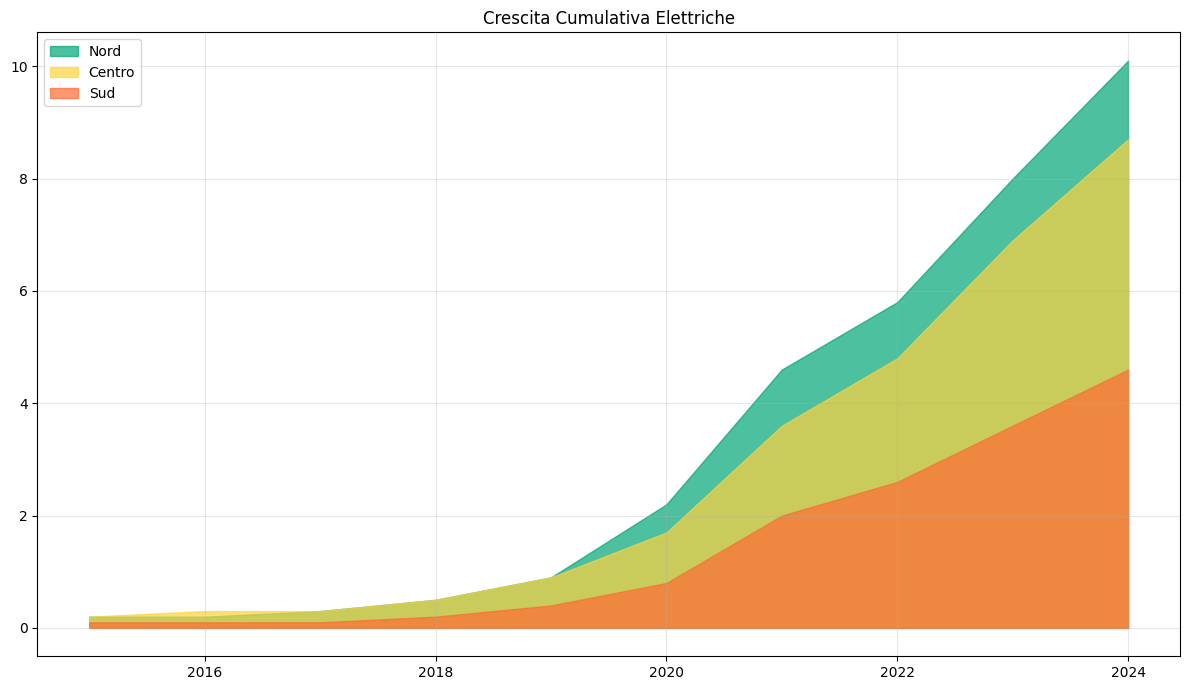

In [15]:
# VARIANTE 2: Area Stacked


fig, ax = plt.subplots(figsize=(12, 7))

for area in AREE:
    ax.fill_between(ANNI, get_vals(area), alpha=0.7, color=COLORI[area], label=area)

ax.legend()
ax.grid(alpha=0.3)
ax.set_title('Crescita Cumulativa Elettriche')
plt.tight_layout()
plt.show()

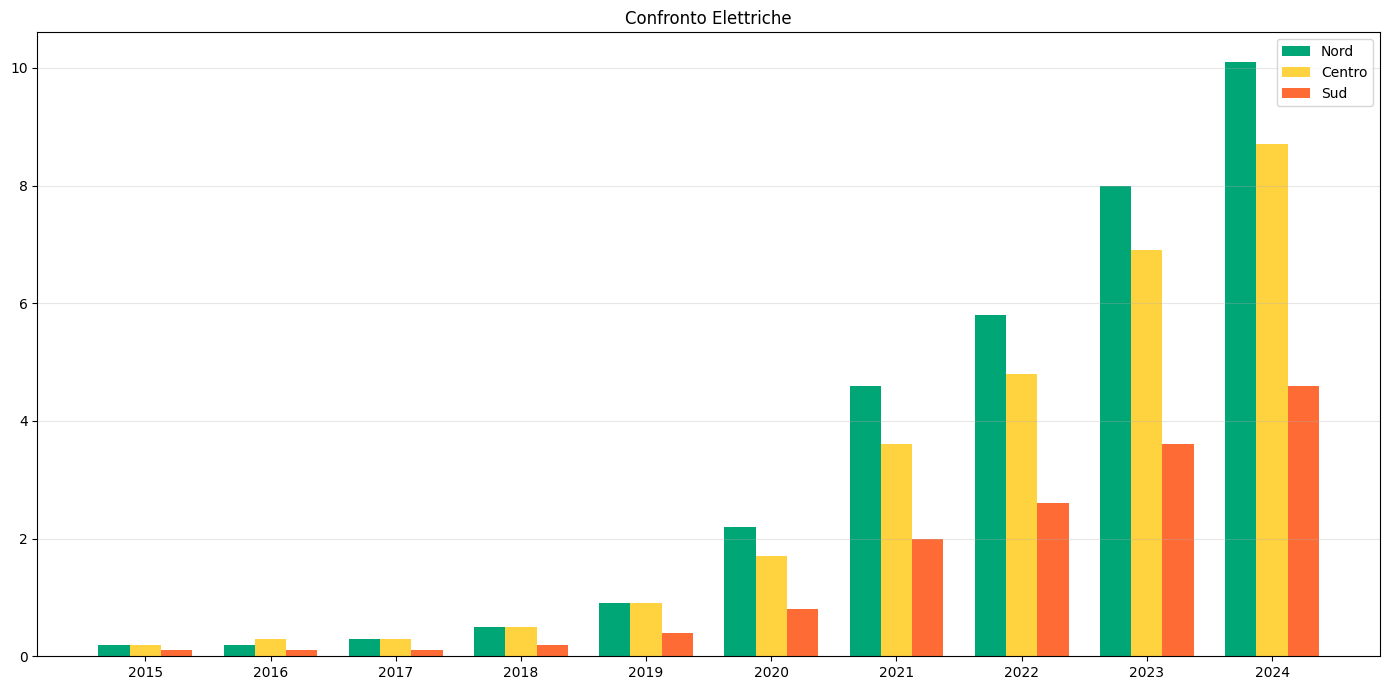

In [22]:
# VARIANTE 3: Barre
anni = sorted(set(df_el_aree['TIME_PERIOD']))
x = np.arange(len(anni))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

offsets = np.linspace(-width, width, len(AREE))
for area, offset in zip(AREE, offsets):
    ax.bar(x + offset, get_vals(area), width, label=area, color=COLORI[area])

ax.set_xticks(x)
ax.set_xticklabels(anni)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_title('Confronto Elettriche')
plt.tight_layout()
plt.show()

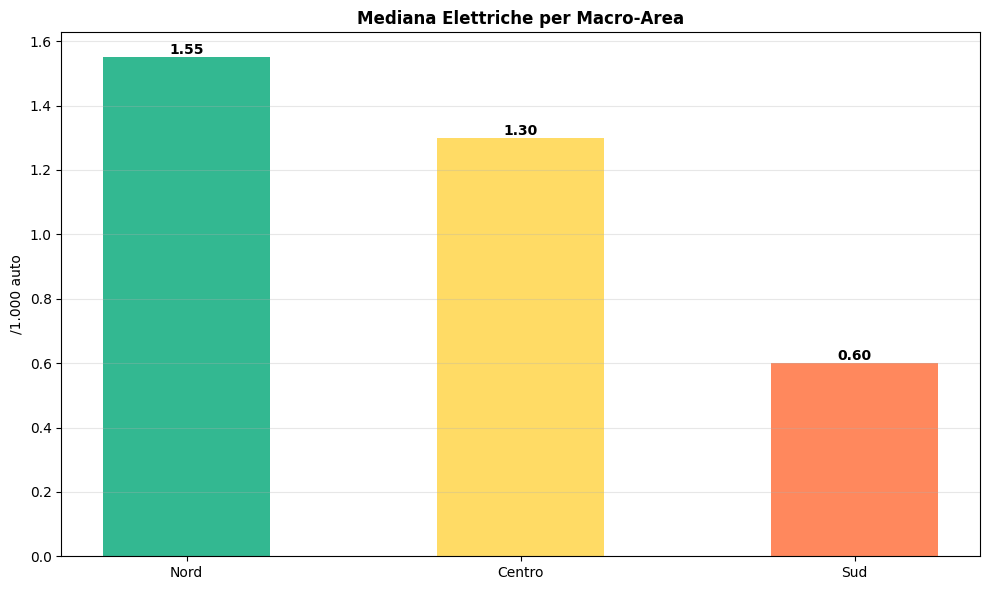

In [23]:
# VARIANTE 13: Mappa Italia Semplice (colori per area)
val_med = [df_el_aree[df_el_aree['Territorio']==a]['Osservazione'].median() for a in AREE]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(AREE, val_med, color=COLORI.values(), alpha=0.8, width=0.5)

# Aggiungi valori
for bar, val in zip(bars, val_med):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.2f}', ha='center', fontweight='bold')

ax.set_title('Mediana Elettriche per Macro-Area', fontweight='bold')
ax.set_ylabel('/1.000 auto')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
